# Detección de Anomalías en Transacciones con Tarjeta de Crédito
**Enfoque:** Aprendizaje no supervisado.

## 1. Introducción y Planteamiento del Problema

El fraude con tarjeta de crédito es un problema de alta relevancia en sistemas financieros: ocurre con baja frecuencia pero con consecuencias económicas significativas. El objetivo de este proyecto es construir un sistema capaz de detectar transacciones fraudulentas de forma automática.

### Tipo de aprendizaje

El enfoque adoptado es no supervisado. Los modelos se entrenan exclusivamente con transacciones legítimas y aprenden a representar el comportamiento normal. Una transacción se considera sospechosa cuando se desvía significativamente de ese comportamiento aprendido.

### Modelos evaluados

- **Isolation Forest:** aislamiento aleatorio en árboles (S5).
- **Local Outlier Factor (k=20):** anomalías por densidad local (S6).
- **Autoencoder:** error de reconstrucción sobre transacciones normales (S7).

### Criterio de evaluación y decisión

- Métricas: precision, recall, F1, AUC-ROC y PR-AUC.
- El umbral lo calibramos en validación y las métricas finales de la comparativa se reportan en test.
- Vamos a priorizar el f1 que es un balance entre precision y recall, igual que en las secciones 5 a 7.
- Modelo final los escogemos en la sección 8.

Las etiquetas de clase disponibles en el dataset `is_fraud` se reservan exclusivamente para evaluar el desempeño de los modelos, no para entrenarlos.

### Variables

- **Entrada:** características de la transacción derivadas del dataset. Las variables exactas que ingresan al modelo se definen en la sección 4, tras el análisis exploratorio y el preprocesamiento.
- **Salida (por modelo):** nivel de anomalía (un rango entre 0 y 1) y una etiqueta binaria (Normal / Anómalo).

## 2. Descripción del Dataset

El dataset utilizado es **Fraud_detection**, publicado en Kaggle por reemkasaab. Fue generado mediante la herramienta Sparkov Data Generation creada por Brandon Harris, que simula transacciones con tarjeta de crédito a partir de perfiles de comportamiento definidos por parámetros como frecuencia de transacciones, distribución de montos por categoría y patrones temporales.

El dataset cubre el período enero 2019 - diciembre 2020 e incluye transacciones simuladas de 1,000 clientes con 800 comerciantes distintos.

**Fuente:** https://www.kaggle.com/datasets/reemkasaab/fraud-detection  
**Licencia:** No especificada

Las dimensiones, distribución de clases, tipos de datos y valores nulos se verifican a continuación directamente sobre el archivo. El archivo cargado presenta 23 columnas: 22 variables del dataset más `Unnamed: 0`, que es el índice numérico del CSV original y no representa información del dominio.

In [1]:
from src.preprocessing import load_data, describe_dataset

df = load_data("data.csv")
describe_dataset(df)

Dimensiones: 1,852,394 filas × 23 columnas

Distribución de clases:
is_fraud
Normal    1842743
Fraude       9651
Name: count, dtype: int64

Porcentaje de fraude: 0.52%

Tipos de datos:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Valores nulos:
Ninguno

Primeras filas:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



Resumen estadístico (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"1,852,394","537,193.44","366,910.96",0.00,"231,549.00","463,098.00","833,575.75","1,296,674.00"
cc_num,"1,852,394","417,386,038,393,710,400.00","1,309,115,265,318,735,104.00","60,416,207,185.00","180,042,946,491,150.00","3,521,417,320,836,166.00","4,642,255,475,285,942.00","4,992,346,398,065,154,048.00"
amt,"1,852,394",70.06,159.25,1.00,9.64,47.45,83.10,"28,948.90"
zip,"1,852,394","48,813.26","26,881.85","1,257.00","26,237.00","48,174.00","72,042.00","99,921.00"
lat,"1,852,394",38.54,5.07,20.03,34.67,39.35,41.94,66.69
long,"1,852,394",-90.23,13.75,-165.67,-96.80,-87.48,-80.16,-67.95
city_pop,"1,852,394","88,643.67","301,487.62",23.00,741.00,"2,443.00","20,328.00","2,906,700.00"
unix_time,"1,852,394","1,358,674,218.83","18,195,081.39","1,325,376,018.00","1,343,016,823.75","1,357,089,331.00","1,374,581,485.25","1,388,534,374.00"
merch_lat,"1,852,394",38.54,5.11,19.03,34.74,39.37,41.96,67.51
merch_long,"1,852,394",-90.23,13.76,-166.67,-96.90,-87.44,-80.25,-66.95


### Limitaciones del dataset

- **Naturaleza sintética:** generado por simulación, por lo que puede no cubrir todos los patrones reales de fraude.
- **Licencia no especificada:** limita su uso fuera del ámbito educativo y analítico.
- **Período acotado:** dos años de datos pueden introducir sesgo temporal si los patrones de fraude han cambiado.
- **Sin descripción oficial de columnas:** el dataset no incluye un diccionario de datos formal.

## 3. Análisis Exploratorio (EDA)

Antes de modelar, se exploran los patrones del dataset para entender la naturaleza de los datos y fundamentar las decisiones de preprocesamiento. El EDA busca responder cinco preguntas clave:

1. ¿Qué tan desbalanceado está el dataset?
2. ¿Los montos de transacciones fraudulentas difieren de las normales?
3. ¿Hay categorías de comercio con mayor incidencia de fraude?
4. ¿El fraude sigue patrones temporales (hora del día, día de la semana)?
5. ¿Existe diferencia en la tasa de fraude entre géneros?

In [2]:
from src.eda import (
    plot_class_distribution, plot_amount_by_class, plot_fraud_by_category,
    plot_time_patterns, plot_fraud_by_gender
)

Distribución de clases:
  Normal: 1,842,743 (99.48%)
  Fraude: 9,651 (0.52%)


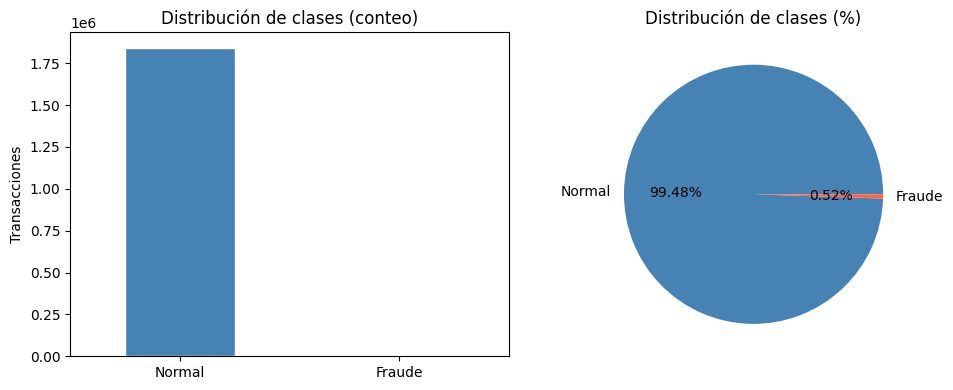

In [3]:
# 1. ¿Qué tan desbalanceado está el dataset?
plot_class_distribution(df)

El dataset está muy desbalanceado. De casi dos millones de transacciones, solo 9 651 son fraude. En el gráfico de barras la barra de fraude es prácticamente invisible, y en el otro gráfico circular vemos lo mismo, es casi todo normal. Eso nos dice que para este proyecto no nos sirve mirar solo la métrica de accuracy porque un modelo que siempre diga que es normal tendría un 99,48%. Que haya fraude en este dataset en raro, también por eso vamos a utilizar modelos de detección de anomalías.

Estadísticas de monto por clase:
              count        mean         std   min      25%     50%      75%       max
is_fraud                                                                             
Normal    1842743.0   67.651278  153.548108  1.00    9.610   47.24   82.560  28948.90
Fraude       9651.0  530.661412  391.028873  1.06  240.075  390.00  902.365   1376.04


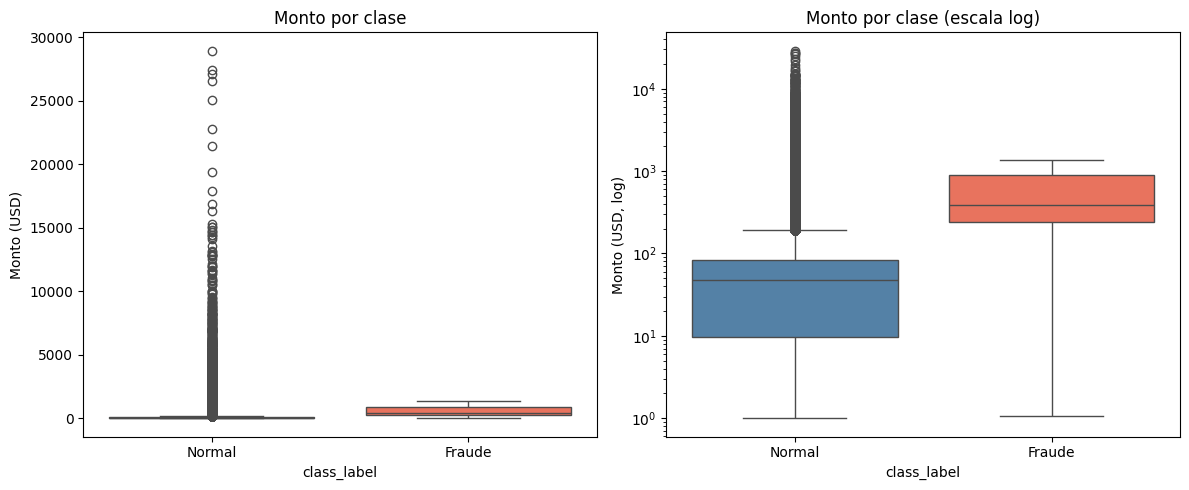

In [4]:
# 2. ¿Los montos de transacciones fraudulentas difieren de las normales?
plot_amount_by_class(df)

En el gráfico de la izquierda, con escala de dinero normal, la caja de fraude apenas se ve, y la normal no. Lo que más se ve son los montos altos de las transacciones normales porque tienen montos mucho mas altos que las fraudulentas. El gráfico de la derecha en escala log es para que se entienda mejor todo.

En la de la derecha vemos que la mediana de normales es 47,24 dólares y la de fraude es 390, o sea bastante más. Además, el 75% de las normales queda por debajo de 82,56 dólares, y eso que ni siquiera llega al 25% del fraude, que empieza alrededor de 240. Esto nos dice que muchas transacciones fraudulentas tienen montos mayores que la mayoría de las normales.

Otra cosa que notamos es que los montos más altos del dataset son de transacciones normales. El fraude no llega hasta ahí, sino hasta 1 376 dólares y la mayoría cae en un rango más limitado de entre unos 240 y 902. Entonces el monto sí aporta para detectar fraude y por eso lo vamos a usar en los modelos, junto con su versión en log.

Tasa de fraude por categoría (%):
category
shopping_net      1.59
misc_net          1.30
grocery_pos       1.26
shopping_pos      0.63
gas_transport     0.41
misc_pos          0.28
grocery_net       0.27
travel            0.27
personal_care     0.22
entertainment     0.22
kids_pets         0.19
food_dining       0.16
home              0.15
health_fitness    0.15


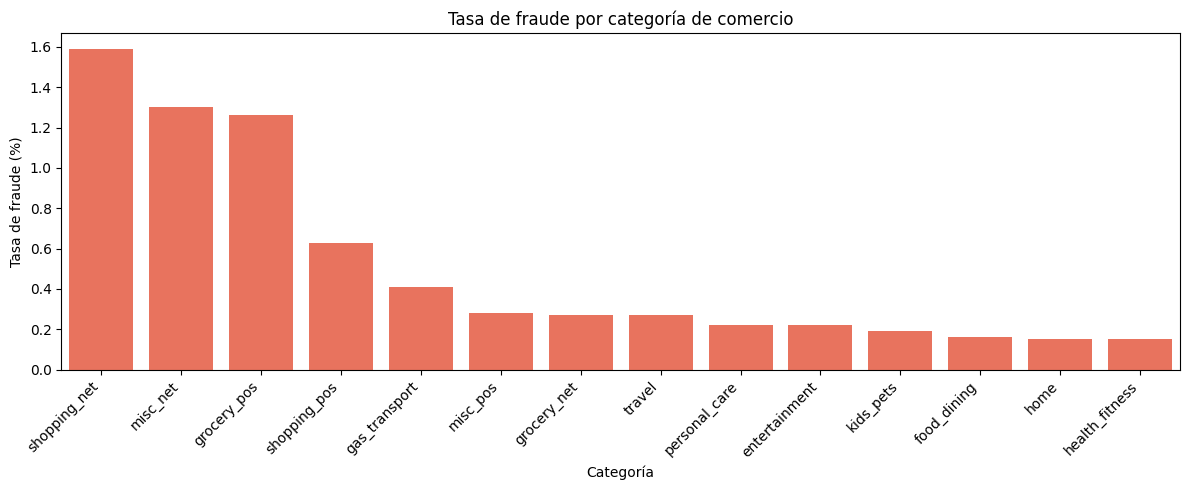

In [5]:
# 3. ¿Hay categorías de comercio con mayor incidencia de fraude?
plot_fraud_by_category(df)

En este gráfico vemos que la tasa de fraude no es la misma en todos los tipos de comercio. Las barras más altas están a la izquierda: shopping_net llega a 1,59%, le siguen misc_net con 1,30% y grocery_pos con 1,26%. Hacia la derecha las barras van bajando y al final home y health_fitness quedan en 0,15%.

Eso nos dice que el fraude sigue siendo raro en todas las categorías, pero la probabilidad cambia bastante según dónde se hizo la compra. Entre la categoría con más fraude y las que tienen menos hay mucha diferencia.

También notamos que dos de las tres categorías con más fraude son shopping_net y misc_net, lo cual tiene sentido porque son compras en línea, deberia ser más facil hacer fraude en internet. Por eso la categoría del comercio sí nos sirve como variable y la vamos a incluir en los modelos.

Tasa de fraude por hora:
hour
0     1.36
1     1.35
2     1.30
3     1.32
4     0.10
5     0.13
6     0.09
7     0.12
8     0.10
9     0.10
10    0.09
11    0.10
12    0.09
13    0.10
14    0.11
15    0.11
16    0.10
17    0.10
18    0.12
19    0.11
20    0.11
21    0.11
22    2.60
23    2.55

Tasa de fraude por día:
weekday
Lunes        0.40
Martes       0.47
Miércoles    0.61
Jueves       0.64
Viernes      0.64
Sábado       0.57
Domingo      0.46


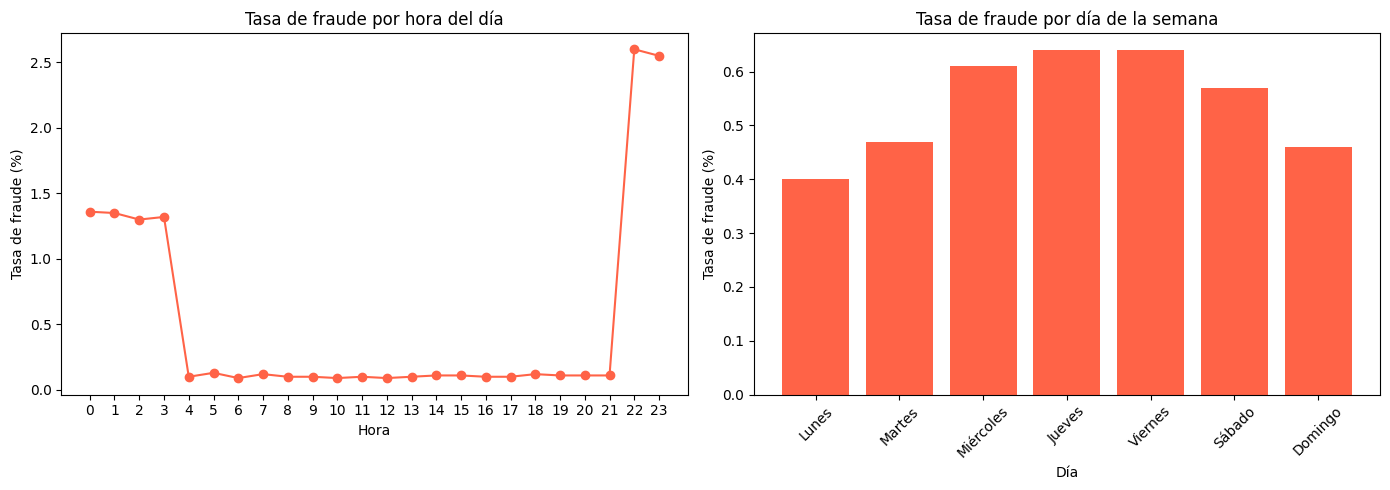

In [6]:
# 4. ¿El fraude sigue patrones temporales?
plot_time_patterns(df)

En el gráfico de la izquierda vemos que dependiendo de la hora del día sí cambia mucho la tasa de fraude. De la 4 a.m a las 9 p.m casi no hay fraude. Pero entre las 12 a.m y las 3 a.m la tasa sube muchísimo. O sea, el fraude se concentra en la madrugada y al final de la noche, no en horario normal del día.

Eso nos dice que la hora de la transacción puede ayudar al modelo, sobre todo porque en esas horas el titular probablemente no está pendiente de alertas. Por eso vamos a sacar la hora y también una variable de si es de noche, en el preprocesamiento.

En el gráfico de la derecha, por día de la semana, prácticamente no hay diferencia entre dia y dia. Se nota un poco más de fraude a mitad de semana, pero no es tanto como con las horas. Igual vamos a incluir el dia de la semana porque suma información.

Tasa de fraude por género:
   Género   Total  Fraudes  Tasa (%)
 Femenino 1014749     4899      0.48
Masculino  837645     4752      0.57


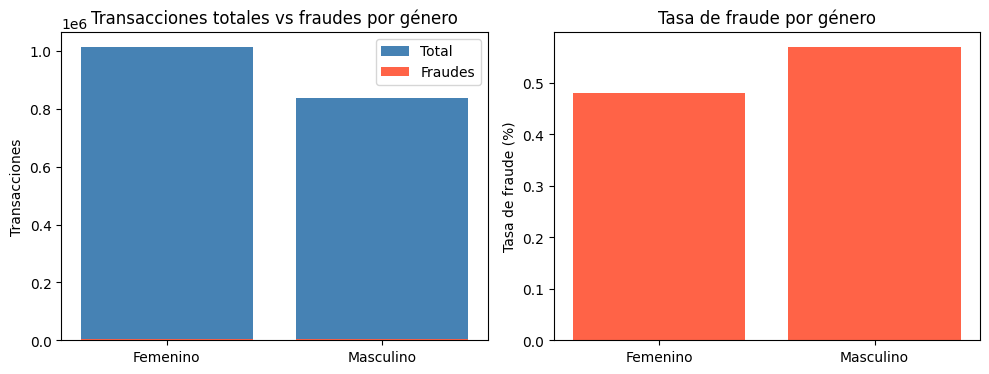

In [7]:
# 5. ¿Existe diferencia en la tasa de fraude entre géneros?
plot_fraud_by_gender(df)

En el gráfico de la izquierda vemos que hay más transacciones femeninas que masculinas, pero en ambos casos el fraude es prácticamente invisible.

En el de la derecha, el fraude se parece mucho: 0,48% en femenino y 0,57% en masculino. Hay un poco más en masculino, pero la diferencia es muy pequeña.

Eso nos dice que el género casi no ayuda a predecir fraude en este dataset. Además, usarlo en el modelo podría meter sesgo. Por eso no lo vamos a incluir como variable en los modelos. Más adelante lo comentamos en el análisis crítico.

## 4. Preprocesamiento

### Análisis de columnas numéricas

Min, max y rango por columna numérica:
                         min                          max                  value_range
cc_num     60,416,207,185.00 4,992,346,398,065,154,048.00 4,992,346,337,648,947,200.00
unix_time   1,325,376,018.00             1,388,534,374.00                63,158,356.00
city_pop               23.00                 2,906,700.00                 2,906,677.00
Unnamed: 0              0.00                 1,296,674.00                 1,296,674.00
zip                 1,257.00                    99,921.00                    98,664.00
amt                     1.00                    28,948.90                    28,947.90
merch_long           -166.67                       -66.95                        99.72
long                 -165.67                       -67.95                        97.72
merch_lat              19.03                        67.51                        48.48
lat                    20.03                        66.69                        46.67
is_f

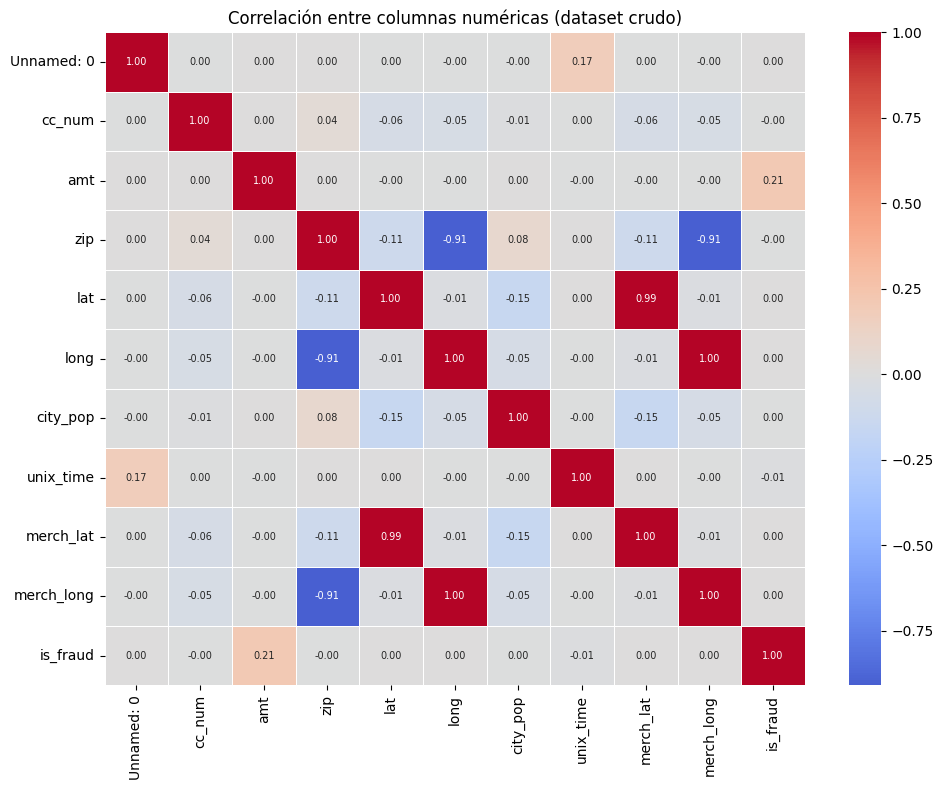

In [8]:
from src.eda import plot_numeric_analysis

plot_numeric_analysis(df)

En la tabla vemos que cc_num son números de tarjeta enormes. Solo identifican la tarjeta. Unnamed: 0 va de 0 hasta más de un millón, como un número de fila. Como no ayudan entonces las sacamos en la limpieza.

unix_time también hay como uno por fila. La fecha útil para nosotros está en trans_date_trans_time, y de ahí sacamos la hora y si es de noche. Entonces unix_time la quitamos.

En el mapa de correlación, zip se parece mucho a long y a merch_long. O sea, el código postal prácticamente repite lo que ya dicen las coordenadas. Por eso zip no lo dejamos.

Las latitudes y longitudes del cliente y del comercio son super parecidas: lat con merch_lat y long con merch_long. Meter las cuatro por separado sería repetitivo. Creemos que es mejor si hacemos una sola variable que sea la distancia de un punto al otro.

El amt es la variable numérica que más se relaciona con is_fraud en este mapa. Eso va con lo que ya vimos en el EDA del monto, así que amt sí la conservamos. city_pop y el resto que quedan los vemos después de la limpieza y el feature engineering.

### Análisis de columnas de texto

Cardinalidad de columnas de texto (valores únicos):
trans_num                1852394
trans_date_trans_time    1819551
street                       999
dob                          984
city                         906
merchant                     693
job                          497
last                         486
first                        355
state                         51
category                      14
gender                         2


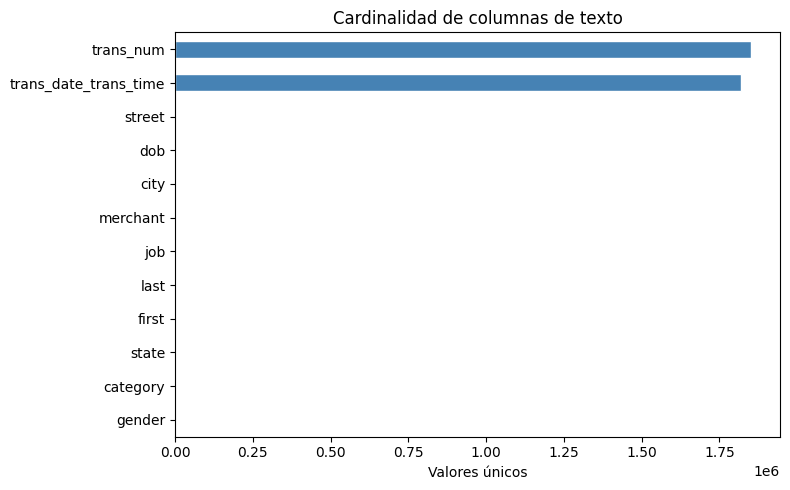

In [9]:
from src.eda import plot_text_analysis

plot_text_analysis(df)

En el gráfico de cardinalidad vemos que trans_num y trans_date_trans_time son las que más valores distintos tienen. Las demás columnas quedan muy abajo en comparación.

trans_num tiene un valor distinto por transacción, es un identificador. Lo sacamos en la limpieza.

trans_date_trans_time podemos usarla para sacar la hora y el día, en el feature engineering. Después la quitamos.

street, first y last tienen cientos de valores, más o menos acorde con ser datos de personas del dataset. Son información personal entonces las eliminamos.

dob tiene muchas fechas distintas. No la vamos a meter así, mejor calculamos la edad y luego quitamos dob.

merchant tiene muchos comercios distintos. Para saber el tipo de negocio nos basta category, que solo tiene 14 valores, así que merchant no la dejamos.

city y state repiten la idea de ubicación, mejor dejamos lo de la distancia que después haremos.

job tiene muchos valores diferentes y en la matriz de correlación vimos que no aportaba nada, así que tampoco la usamos.

gender ya en el análisis EDA dijimos que la ibammos a eliminar.

category sí la conservamos para hacerle lo del one-hot encoder.

### Limpieza

In [10]:
from src.preprocessing import clean_data

df_clean = clean_data(df)
print(f"Columnas tras limpieza ({df_clean.shape[1]}): {list(df_clean.columns)}")

Columnas tras limpieza (10): ['trans_date_trans_time', 'category', 'amt', 'lat', 'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud']


### Feature Engineering

Variables derivadas de columnas que no entran directo al modelo. Las originales se eliminan tras crearlas.

- **hour, day_of_week e is_night**: extraídos de trans_date_trans_time. El EDA mostró que el fraude se concentra en la madrugada y al final de la noche, mientras que en horario diurno la tasa es mucho menor.
- **log_amt**: transformación logarítmica de amt. Reduce el efecto de montos extremos en transacciones normales y complementa el análisis del monto del EDA.
- **age**: calculada a partir de dob. Convierte la fecha de nacimiento en años del titular.  
- **distance**: distancia en kilómetros entre la ubicación de la persona (lat, long) y la del comercio (merch_lat, merch_long), para detectar compras inusualmente lejos. Las cuatro coordenadas las borraremos después.
- **`cat_*`**: codificación one-hot de category. El EDA mostró que la tasa de fraude varía según el tipo de comercio.

In [11]:
from src.preprocessing import feature_engineering

df_feat = feature_engineering(df_clean)
print(f"Columnas tras feature engineering ({df_feat.shape[1]}): {list(df_feat.columns)}")

Columnas tras feature engineering (23): ['amt', 'city_pop', 'is_fraud', 'hour', 'day_of_week', 'is_night', 'log_amt', 'age', 'distance', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']


### Escala y correlación de las features

Tras la limpieza y el feature engineering se revisan las variables que entrarán al modelo:

- **Rangos:** comparar mínimo, máximo y amplitud de cada feature. Si las magnitudes son muy distintas (ejemplo: city_pop y hour), hace falta escalar antes de entrenar.
- **Correlaciones:** comprobar si algún par de variables repite la misma información. Tras el preprocesamiento no debería haber redundancia fuerte entre las features finales.

Min, max y rango por variable numérica:
                     min          max  value_range
city_pop           23.00 2,906,700.00 2,906,677.00
amt                 1.00    28,948.90    28,947.90
distance            0.02       152.12       152.09
age                15.00        96.00        81.00
hour                0.00        23.00        23.00
log_amt             0.69        10.27         9.58
day_of_week         0.00         6.00         6.00
is_night            0.00         1.00         1.00
cat_entertainment   0.00         1.00         1.00
cat_food_dining     0.00         1.00         1.00
cat_gas_transport   0.00         1.00         1.00
cat_grocery_net     0.00         1.00         1.00
cat_grocery_pos     0.00         1.00         1.00
cat_health_fitness  0.00         1.00         1.00
cat_home            0.00         1.00         1.00
cat_kids_pets       0.00         1.00         1.00
cat_misc_net        0.00         1.00         1.00
cat_misc_pos        0.00         1.00     

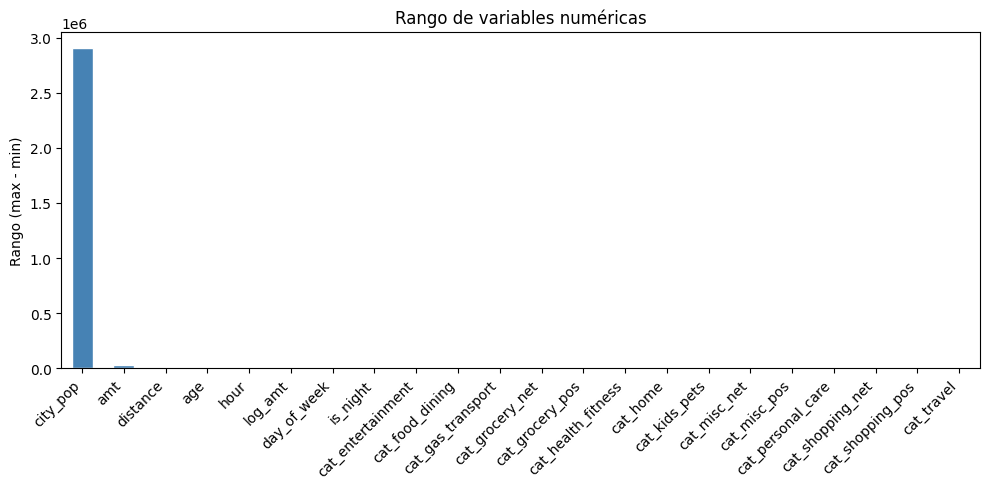

In [12]:
from src.eda import plot_ranges, plot_correlation_matrix

plot_ranges(df_feat.drop(columns=['is_fraud']))

En el gráfico se ve que city_pop manda por magnitud: su rango es enorme comparado con el resto. Si entrenamos así, esa variable pesaría más por el tamaño del número que por lo que aporta al fraude.

Por eso escalamos con StandardScaler, ajustado en train, para que todas las features entren en las mismas condiciones.

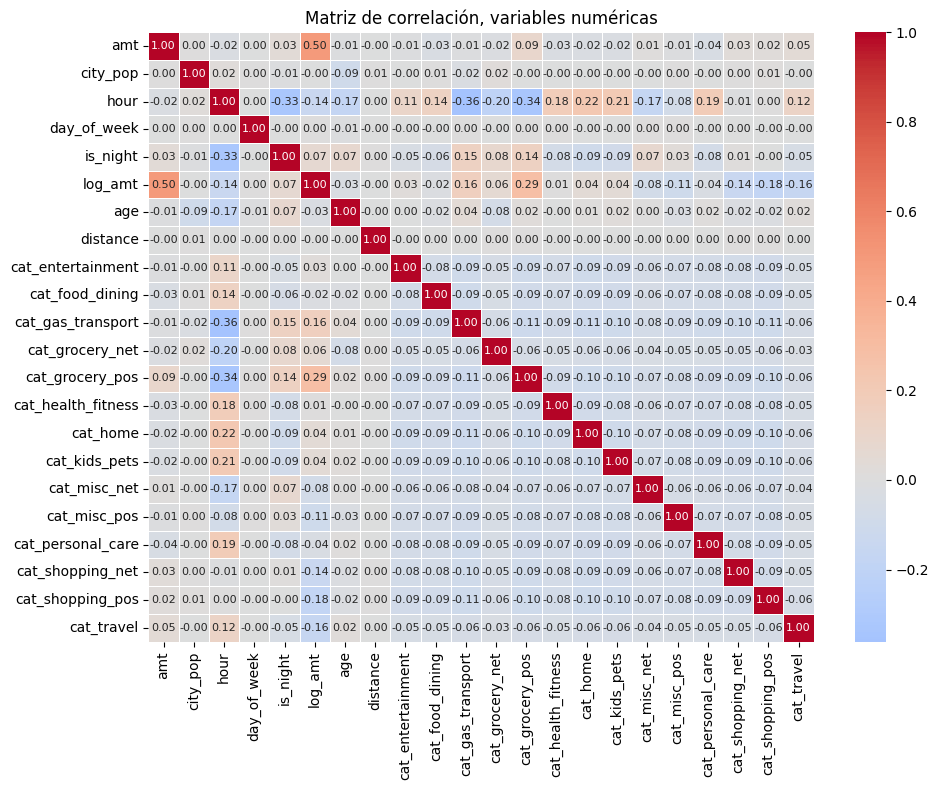

In [13]:
plot_correlation_matrix(df_feat)

En el mapa de correlación casi todo se ve gris, o sea que las variables casi no se repiten entre sí. Eso era lo que queríamos comprobar después del preprocesamiento.

La excepción clara es amt con log_amt, que se ven más rojos con unos 0,50. Eso es normal porque una es la transformación de la otra.

También salen cuadros celestes que son correlaciones negativas. Entre las cat_ pasa porque solo una categoría puede ser 1 por transacción. No es un error. Lo mismo pasa entre hour y otras categorías, que ciertas categorias es usarán mas de dia o de noche. Todo eso está bien.

Lo demás queda cerca de cero, así que seguimos con el escalado y el split sin quitar más columnas.

### División train/validation/test y escalado

Partimos el dataset en tres bloques: 60% train, 20% validation y 20% test, y haciendo que en cada uno se mantenga parecida la proporción de fraude.

En train dejamos solo transacciones normales. Los modelos no supervisados aprenden “cómo se ve lo habitual”; el fraude no entra en el entrenamiento. En validation y test sí quedan fraudes: val sirve para elegir umbrales y comparar modelos; test lo usamos al final para reportar resultados, sin haberlo usado antes para ajustar nada.

El escalado va aparte del split. Ajustamos StandardScaler solo con train y con esos mismos parámetros escalamos train, val y test. Si el scaler viera val o test, estaríamos filtrando información del futuro al modelo.

In [14]:
import os
import numpy as np
import joblib
from src.preprocessing import split_data_three_way, scale_splits

X_train, X_val, X_test, y_train, y_val, y_test, contamination_rate = split_data_three_way(
    df_feat, val_size=0.2, test_size=0.2, random_state=42
)
X_train_sc, X_val_sc, X_test_sc, scaler = scale_splits(X_train, X_val, X_test)

print(f"Train (solo normales): {X_train_sc.shape}")
print(f"Val:  {X_val_sc.shape},  Fraudes en val:  {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"Test: {X_test_sc.shape},  Fraudes en test: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"Contaminación (dataset): {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")
print(f"Fraudes en y_train → {y_train.sum()}")

Train (solo normales): (1105645, 22)
Val:  (370479, 22),  Fraudes en val:  1,930 (0.52%)
Test: (370479, 22),  Fraudes en test: 1,930 (0.52%)
Contaminación (dataset): 0.0052 (0.52%)
Fraudes en y_train → 0


## 5. Modelo 1: Isolation Forest

Isolation Forest es un algoritmo de detección de anomalías basado en **aislamiento aleatorio**. La idea central es que los puntos anómalos son mucho más fáciles de aislar del resto de los datos que los puntos normales.

El algoritmo construye múltiples árboles de decisión aleatorios. En cada nodo elige aleatoriamente una variable y un punto de corte dentro de su rango, dividiendo los datos de forma recursiva hasta que cada punto queda aislado en su propia hoja. Lo que determina si una transacción es anómala es cuántos pasos se necesitaron para aislarla.

**Las transacciones normales** están agrupadas con otras similares, por lo que requieren muchas divisiones para quedar solas en una hoja. El camino hasta aislarlas es largo.

**Las transacciones anómalas** están lejos del grupo mayoritario, por lo que se aíslan en muy pocos pasos. El camino es corto.

La fórmula que lo define formalmente es:

$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

Un score cercano a 1 indica que la transacción fue fácil de aislar y es probablemente anómala, mientras que un score cercano a 0.5 indica que se comporta como una transacción normal típica.

### Hiperparámetros principales

| Hiperparámetro | Valor usado | Descripción |
|---|---|---|
| `n_estimators` | 100 | Número de árboles del ensamble. Más árboles producen resultados más estables pero aumentan el tiempo de entrenamiento. |
| `contamination` | 0.0052 (calculado dinámicamente) | Proporción esperada de anomalías en los datos. Define el umbral interno del score que separa normal de anómalo. |
| `max_samples` | `"auto"` | Número de muestras que recibe cada árbol. Por defecto toma min(256, n_muestras). |
| `random_state` | 42 | Semilla aleatoria para garantizar la reproducibilidad de los resultados. |

### Entrenamiento

El modelo se entrena exclusivamente con transacciones normales. La tasa de contaminación (0.52%) se calcula sobre el conjunto completo y se usa para fijar el umbral interno del score.

In [15]:
from src.pipeline import run_isolation_forest, print_detection_summary, report_f1_threshold
from src.evaluation import (
    get_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_score_distribution,
)

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

bundle_if = run_isolation_forest(X_train_sc, X_val_sc, X_test_sc, contamination_rate)
iforest = bundle_if.model
if_labels = bundle_if.labels
if_scores = bundle_if.scores
if_scores_val = bundle_if.scores_val
print_detection_summary(if_labels, y_test)

Tasa de fraude en dataset: 0.0052 (0.52%)
Transacciones marcadas como anomalas : 2,329  (0.63%)
Fraudes reales en test               : 1,930  (0.52%)


Al evaluar sobre el conjunto de prueba, el modelo marcó 2,329 transacciones como anómalas (0.63% del total), ligeramente por encima de la tasa real de fraude de 0.52%, lo cual es esperable dado que contamination define un umbral aproximado, no un conteo exacto.

### Evaluación

Dado el desbalance extremo del dataset, la accuracy no es una métrica útil: un modelo que siempre predice Normal alcanzaría 99.48% de exactitud sin detectar un solo fraude. El análisis se centra en precision (qué fracción de las alertas son fraudes reales), recall (qué fracción de los fraudes reales fueron detectados), F1 (el balance entre ambas) y PR-AUC (el área bajo la curva Precision-Recall, que es la métrica más informativa cuando las clases están tan desbalanceadas).

In [16]:
if_metrics = get_metrics(y_test.values, if_labels, if_scores, model_name="Isolation Forest")


  Isolation Forest
  Accuracy : 0.9913
  Precision: 0.2211
  Recall   : 0.2668
  F1       : 0.2418
  AUC-ROC  : 0.8996
  PR-AUC   : 0.1258



Con el umbral de contaminación, el modelo detectó 515 de los 1,930 fraudes reales (recall de 26.68%) con una precisión del 22.11%: de cada 100 alertas que lanza el modelo, aproximadamente 22 corresponden a fraudes reales y las 78 restantes son falsas alarmas. El F1 resultante es 0.2418.

El AUC-ROC de 0.8996 indica que el score continuo tiene buena capacidad discriminativa: en casi el 90% de los casos el modelo asigna un score más alto al fraude que a una transacción normal elegida al azar. El PR-AUC de 0.1258, si bien parece bajo en términos absolutos, está 24 veces por encima del clasificador aleatorio (0.0052), lo que confirma que el modelo aporta valor real sobre la clase minoritaria.

### Matriz de Confusión

La matriz de confusión desglosa los resultados en cuatro categorías: Verdaderos Positivos (fraudes detectados correctamente), Falsos Negativos (fraudes que el modelo no detectó), Falsos Positivos (transacciones normales marcadas como fraude) y Verdaderos Negativos (transacciones normales correctamente identificadas). En detección de fraude el error más costoso son los Falsos Negativos, porque representan fraudes que pasaron sin ser detectados.

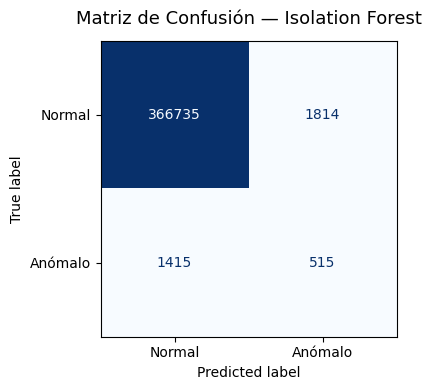

In [17]:
plot_confusion_matrix(y_test.values, if_labels, model_name="Isolation Forest")

De los 1,930 fraudes reales en test, el modelo detectó 515 correctamente y dejó pasar 1,415 sin marcar. De las 368,549 transacciones normales, solo 1,814 fueron marcadas erróneamente como fraude, lo que representa menos del 0.5% de las transacciones legítimas. El costo principal del modelo está en los Falsos Negativos: más de 7 de cada 10 fraudes no son detectados.

### Curva ROC

La curva ROC grafica el recall frente a la tasa de falsos positivos para todos los umbrales posibles del score de anomalía. A diferencia de las métricas anteriores que dependen de un umbral fijo, el AUC-ROC evalúa la calidad del score continuo en su totalidad y no se ve afectado por el valor de contaminación configurado durante el entrenamiento. Un AUC de 0.5 equivale a clasificación aleatoria y 1.0 a separación perfecta.

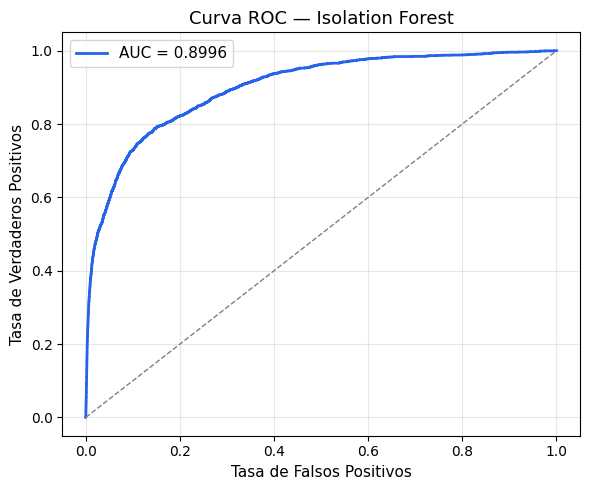

In [18]:
plot_roc_curve(y_test.values, if_scores, model_name="Isolation Forest")

La curva sube abruptamente en la esquina superior izquierda: con una tasa de falsos positivos inferior al 10%, el modelo ya recupera cerca del 80% de los fraudes. El AUC de **0.8996** confirma que el score de anomalía tiene una separación real entre clases, no solo aparente.

### Distribución del Score de Anomalía

El histograma muestra cómo distribuye el modelo los scores de anomalía para cada clase real. Una buena separación entre las dos curvas indica que el modelo asigna scores sistemáticamente más altos a los fraudes. El solapamiento entre ambas distribuciones revela cuántos fraudes tienen scores similares a los de transacciones normales, lo que anticipa las limitaciones del modelo independientemente del umbral que se elija.

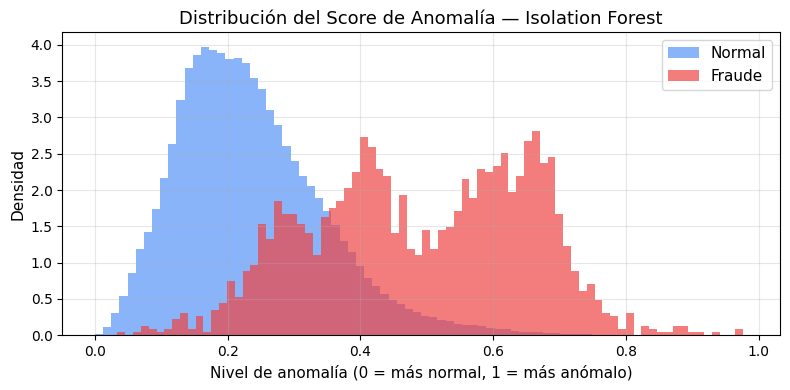

In [19]:
plot_score_distribution(if_scores, y_test.values, model_name="Isolation Forest")

Las transacciones normales forman una distribución concentrada con pico alrededor de 0.15-0.20 y cola que se desvanece cerca de 0.40. Los fraudes en cambio se distribuyen de forma mucho más dispersa entre 0.20 y 0.85, con dos picos visibles cerca de 0.40 y 0.65, lo que sugiere que no todos los fraudes son igualmente fáciles de detectar. Hay un subgrupo que el modelo identifica con alta confianza (scores mayores a 0.55) y otro que cae en la zona gris.

La zona de solapamiento entre 0.20 y 0.40 es donde el modelo tiene mayor dificultad. Ahí conviven transacciones normales con cola alta y fraudes con score bajo, y cualquier umbral que se fije en esa región va a generar tanto falsas alarmas como fraudes no detectados.

### Curva Precision-Recall

La curva Precision-Recall es la métrica más informativa en problemas con desbalance extremo porque no se ve inflada por los Verdaderos Negativos. Muestra cómo varía el balance entre precision y recall al mover el umbral de decisión, y permite elegir el corte que mejor se adapta al costo operativo del sistema. El punto rojo marca el umbral que maximiza el F1 sobre el conjunto de validación.

Umbral calibrado en val (max F1): 0.6078


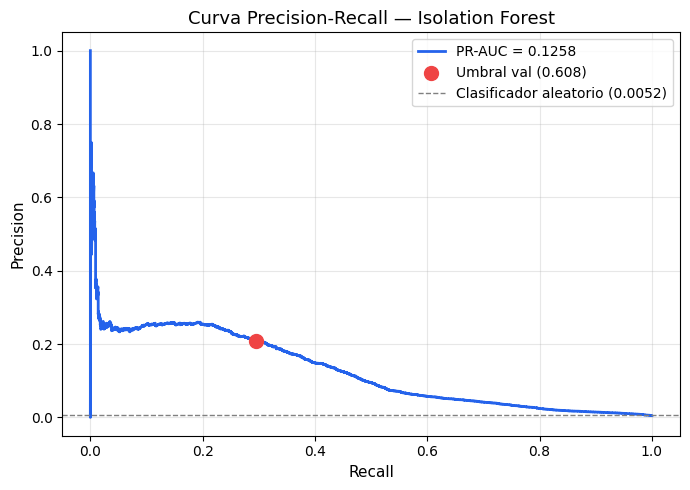


  Isolation Forest (umbral val → test)
  Accuracy : 0.9905
  Precision: 0.2092
  Recall   : 0.2943
  F1       : 0.2446
  AUC-ROC  : 0.8996
  PR-AUC   : 0.1258



In [20]:
best_thresh, if_labels_opt, if_metrics_opt = report_f1_threshold(
    y_val, if_scores_val, y_test, if_scores, "Isolation Forest"
)

La curva cae abruptamente desde precision 1.0 en recalls muy bajos, lo que significa que el modelo solo es muy preciso cuando alerta sobre muy pocas transacciones. A partir de recall 0.05 la precision se estabiliza en torno a 0.25 y se mantiene relativamente plana hasta recall 0.30, que es la zona donde se ubica el umbral óptimo de validación (0.608, punto rojo). Ahí la precision es aproximadamente 0.21, lo que significa que 1 de cada 5 alertas corresponde a un fraude real.

A partir de recall 0.40 la curva cae de forma sostenida hacia cero, lo que refleja que forzar al modelo a detectar más fraudes tiene un costo alto en falsas alarmas.

El PR-AUC de 0.1258 está muy por encima del clasificador aleatorio (0.0052). Esa diferencia de 24 veces confirma que el modelo aporta valor real, aunque el margen de mejora sigue siendo amplio.

El rendimiento limitado refleja una restricción inherente del algoritmo: Isolation Forest detecta transacciones que son estadísticamente poco comunes en el conjunto global, pero no necesariamente las que son anómalas respecto a su entorno local. Esta limitación motiva el uso de LOF en la sección 6, que aborda el problema desde la densidad local, y del Autoencoder en la sección 7, que lo hace desde el error de reconstrucción.

## 6. Modelo 2: Local Outlier Factor (LOF)

Local Outlier Factor (LOF) es un algoritmo de detección de anomalías basado en **densidad local**. A diferencia de Isolation Forest, que evalúa qué tan fácil es aislar un punto del conjunto completo, LOF compara la densidad de cada punto con la de sus vecinos más cercanos.

La idea central es que un punto normal está rodeado de puntos con una densidad similar a la suya. Un punto anómalo, en cambio, tiene una densidad mucho más baja que la de sus vecinos: se encuentra en una región dispersa rodeada de un vecindario más compacto.

El score LOF de un punto $x$ se define como:

$$\text{LOF}_k(x) = \frac{\overline{\text{lrd}_k(x')}}{\text{lrd}_k(x)}, \quad x' \in N_k(x)$$

donde $\text{lrd}_k(x)$ es la **densidad de alcanzabilidad local** de $x$ respecto a sus $k$ vecinos más cercanos $N_k(x)$. Un LOF $\approx 1$ indica que el punto está en una región de densidad similar a sus vecinos (comportamiento normal). Un LOF $\gg 1$ indica que el punto está en una región mucho menos densa que su vecindario (comportamiento anómalo).

Esta perspectiva **local** complementa la perspectiva **global** de Isolation Forest: mientras IF detecta puntos que se alejan del conjunto completo, LOF detecta puntos que son inusuales dentro de su propio entorno. En el contexto de fraude, esto permite identificar transacciones que no son atípicas en el dataset global pero sí son raras comparadas con transacciones similares cercanas.

Para que LOF pueda evaluar transacciones nuevas sin necesidad de reentrenar, se utiliza `novelty=True`. Este modo almacena el conjunto de entrenamiento y lo usa como referencia para calcular la densidad de cualquier punto nuevo a través de `predict()` y `decision_function()`. Sin este parámetro, LOF solo puede evaluar los puntos sobre los que fue entrenado.

El modelo requiere que las variables estén en la misma escala para que los cálculos de distancia sean comparables. El `StandardScaler` aplicado en la sección 4f garantiza esta condición.

### Hiperparámetros principales

| Hiperparámetro | Valor usado | Descripción |
|---|---|---|
| `n_neighbors` | 20 | Número de vecinos para calcular la densidad local. Valores pequeños hacen el modelo sensible a variaciones locales; valores grandes suavizan la detección. |
| `contamination` | calculado dinámicamente | Proporción esperada de anomalías. Define el umbral del score que separa normal de anómalo. |
| `novelty` | `True` | Habilita la detección sobre datos nuevos no vistos durante el entrenamiento. |
| `n_jobs` | -1 | Usa todos los núcleos disponibles para paralelizar los cálculos de vecinos. |

### Entrenamiento

El modelo se entrena exclusivamente con transacciones normales. LOF aprende la estructura de densidad del comportamiento legítimo y, durante la evaluación, identifica las transacciones cuya densidad local es significativamente menor a la de sus vecinos.

A diferencia de Isolation Forest, LOF no construye árboles sino que almacena todos los puntos de entrenamiento para calcular distancias durante la inferencia. Esto lo hace más preciso en espacios locales pero también más costoso computacionalmente.

**Nota:** con 1.47 millones de transacciones de entrenamiento este paso puede tomar entre 10 y 30 minutos dependiendo del hardware disponible.

In [21]:
from src.pipeline import run_lof, print_detection_summary

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

# Nota: el ajuste puede tardar varios minutos por el tamaño del conjunto de entrenamiento
bundle_lof = run_lof(X_train_sc, X_val_sc, X_test_sc, contamination_rate)
lof = bundle_lof.model
lof_labels = bundle_lof.labels
lof_scores = bundle_lof.scores
lof_scores_val = bundle_lof.scores_val
print_detection_summary(lof_labels, y_test)

Tasa de fraude en dataset: 0.0052 (0.52%)
Transacciones marcadas como anomalas : 2,736  (0.74%)
Fraudes reales en test               : 1,930  (0.52%)


El modelo marcó 2,736 transacciones como anómalas (0.74% del total), por encima de la tasa real de fraude de 0.52%. LOF tiende a ser más generoso que Isolation Forest al marcar transacciones como anómalas porque evalúa la densidad local en lugar de la rareza global.

### Evaluación

Se calculan las mismas métricas que en la sección 5. Como referencia, Isolation Forest obtuvo un F1 de 0.2418 y un PR-AUC de 0.1258 con el umbral de contaminación.

In [22]:
lof_metrics = get_metrics(y_test.values, lof_labels, lof_scores, model_name="Local Outlier Factor")


  Local Outlier Factor
  Accuracy : 0.9919
  Precision: 0.3030
  Recall   : 0.4295
  F1       : 0.3553
  AUC-ROC  : 0.8354
  PR-AUC   : 0.3915



LOF detectó 829 de los 1,930 fraudes reales (recall de 42.95%) con una precisión del 30.30%: de cada 100 alertas, aproximadamente 30 corresponden a fraudes reales. El F1 de 0.3553 representa una mejora del 47% sobre Isolation Forest.

El PR-AUC de 0.3915 es tres veces superior al de Isolation Forest (0.1258), lo que confirma que el score de densidad local tiene una capacidad discriminativa significativamente mejor sobre la clase minoritaria. El AUC-ROC de 0.8354 es algo menor que el de Isolation Forest (0.8996), lo que indica que globalmente el score de LOF separa menos las clases, pero su ventaja se concentra en la zona de alta precision que es la más relevante en la práctica.

### Matriz de Confusión

La matriz de confusión muestra el desglose completo de los resultados. En detección de fraude el foco está en minimizar los Falsos Negativos (fraudes no detectados), aunque un volumen alto de Falsos Positivos también tiene costo operativo porque genera alertas que los analistas deben revisar manualmente.

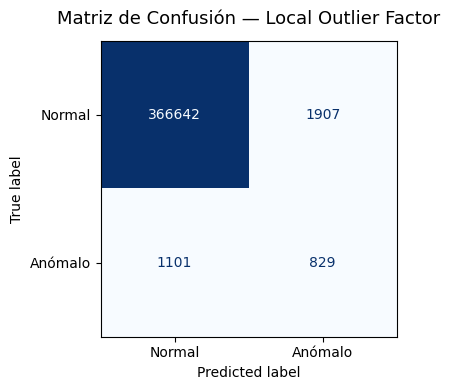

In [23]:
plot_confusion_matrix(y_test.values, lof_labels, model_name="Local Outlier Factor")

De los 1,930 fraudes reales en test, el modelo detectó 829 correctamente y dejó pasar 1,101 sin marcar. Comparado con Isolation Forest, LOF detecta 314 fraudes adicionales con el mismo umbral de contaminación. De las 368,549 transacciones normales, 1,907 fueron marcadas erróneamente como fraude, un volumen similar al de Isolation Forest (1,814).

### Curva ROC

La curva ROC permite comparar la calidad del score continuo de LOF con la de Isolation Forest independientemente del umbral elegido. Un AUC mayor indica que el score separa mejor las clases en términos globales.

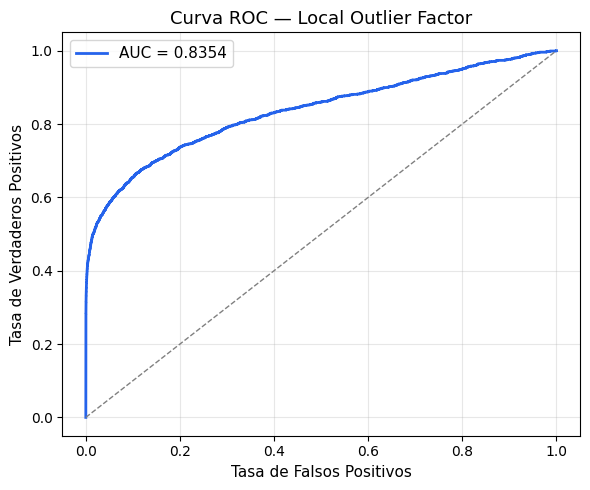

In [24]:
plot_roc_curve(y_test.values, lof_scores, model_name="Local Outlier Factor")

El AUC de 0.8354 es inferior al de Isolation Forest (0.8996), lo que indica que globalmente el score de LOF tiene menor capacidad discriminativa. Sin embargo, la curva PR-AUC cuenta una historia diferente: LOF es mucho más preciso en la zona de recalls bajos, que es donde opera en la práctica un sistema de alertas.

### Distribución del Score de Anomalía

El histograma muestra cómo distribuye LOF los scores de anomalía para cada clase real. A diferencia de Isolation Forest, cuyo score varía entre 0 y 1, el score de LOF se concentra en valores muy bajos cercanos a 0 para la mayoría de las transacciones, con una cola larga hacia la derecha para los casos más anómalos.

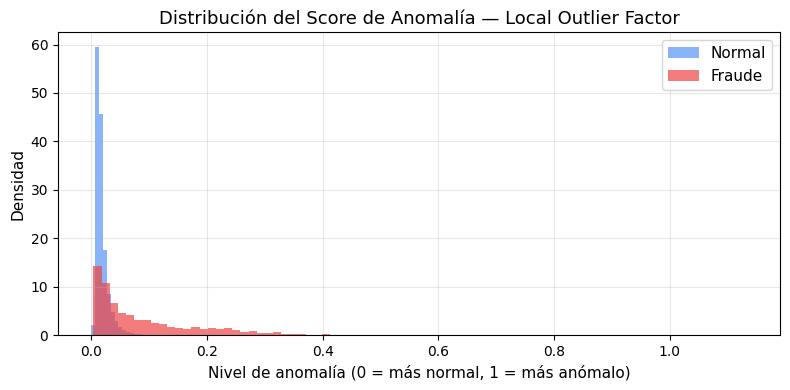

In [25]:
plot_score_distribution(lof_scores, y_test.values, model_name="Local Outlier Factor")

Ambas distribuciones se concentran fuertemente cerca de 0, lo que refleja que LOF considera la gran mayoría de las transacciones como normales con alta confianza. La diferencia entre clases se produce en la cola derecha: los fraudes tienen una proporción mayor de scores entre 0.05 y 0.40, mientras que las transacciones normales caen casi todas por debajo de 0.05.

El solapamiento en la zona cercana a 0 explica por qué el recall con el umbral de contaminación no es perfecto: hay fraudes con scores muy bajos que el modelo no logra distinguir del comportamiento normal.

### Curva Precision-Recall

La curva Precision-Recall de LOF contrasta notablemente con la de Isolation Forest. Mientras que Isolation Forest mostraba una caída abrupta desde el inicio, LOF mantiene una precision muy alta hasta recalls cercanos a 0.25, lo que indica que el modelo puede detectar una fracción importante de los fraudes con muy pocas falsas alarmas.

Umbral calibrado en val (max F1): 0.1042


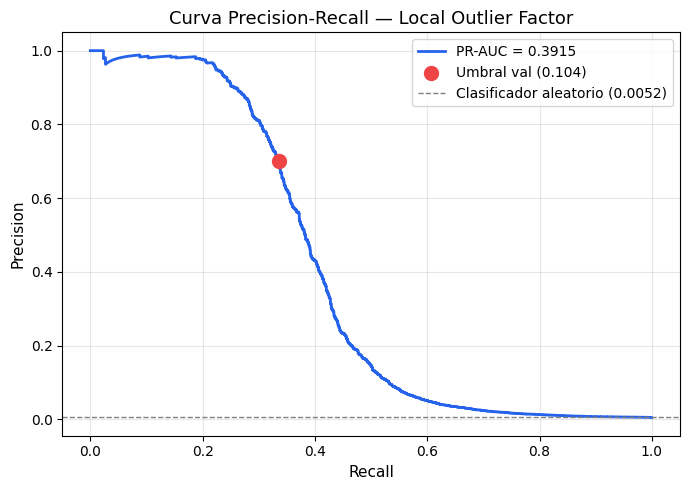


  Local Outlier Factor (umbral val → test)
  Accuracy : 0.9958
  Precision: 0.6998
  Recall   : 0.3358
  F1       : 0.4538
  AUC-ROC  : 0.8354
  PR-AUC   : 0.3915



In [26]:
best_thresh_lof, lof_labels_opt, lof_metrics_opt = report_f1_threshold(
    y_val, lof_scores_val, y_test, lof_scores, "Local Outlier Factor"
)

La curva se mantiene cerca de precision 1.0 hasta recall 0.20 y luego cae de forma pronunciada. El umbral óptimo encontrado en validación es 0.104, que sobre test produce una precision de 69.98% y un recall de 33.58%, con un F1 de 0.4538. Esto significa que con ese umbral casi 7 de cada 10 alertas corresponden a fraudes reales, a costa de detectar solo 1 de cada 3 fraudes.

El PR-AUC de 0.3915 está 75 veces por encima del clasificador aleatorio (0.0052) y es tres veces superior al de Isolation Forest, lo que confirma que LOF tiene una ventaja real en precisión cuando se opera con umbrales conservadores.

La elección del umbral en LOF implica un tradeoff más pronunciado que en Isolation Forest: con el umbral de contaminación se obtiene mejor recall (42.95%) pero menor precision (30.30%), mientras que con el umbral calibrado se invierte la relación (precision 69.98%, recall 33.58%). El umbral óptimo depende del costo operativo del sistema.

LOF supera a Isolation Forest en F1 y PR-AUC, pero su ventaja se concentra en umbrales conservadores. Para detectar más del 43% de los fraudes la precision cae a 30%, lo que puede ser aceptable o no dependiendo de la capacidad del equipo de revisión. Esta limitación motiva el uso del Autoencoder en la sección 7, que aborda el problema desde el error de reconstrucción y puede capturar patrones que ni el aislamiento global ni la densidad local logran detectar.

## 7. Modelo 3: Autoencoder (Red Neuronal)

Un Autoencoder es una red neuronal que aprende a **comprimir** y luego **reconstruir** su propia entrada. El objetivo de entrenamiento no es predecir una etiqueta externa, sino reproducir lo más fielmente posible el dato original después de pasarlo por un cuello de botella.

La red se divide en dos partes:

- **Encoder:** reduce progresivamente la dimensión de la entrada (20 → 16 → 8) hasta llegar al cuello de botella. En ese punto, el modelo ha tenido que resumir la transacción en sus rasgos más esenciales.
- **Decoder:** reconstruye la entrada original a partir de esa representación comprimida (8 → 16 → 20).

Cuando se entrena solo con transacciones normales, el modelo aprende a reconstruir bien el comportamiento legítimo. Al evaluar una transacción nueva, el **error de reconstrucción** (MSE entre la entrada y la salida) indica cuán diferente es de lo normal: un error alto señala una transacción que el modelo no sabe cómo reconstruir, es decir, una anomalía.

$$\text{score}(x) = \frac{1}{d} \sum_{i=1}^{d} (x_i - \hat{x}_i)^2$$

donde $\hat{x}$ es la reconstrucción de $x$ y $d$ es el número de features. Este score se normaliza a [0, 1] para comparabilidad con Isolation Forest y LOF.

La activación `linear` en la capa de salida es la opción correcta cuando los datos están estandarizados con `StandardScaler`: los valores pueden ser negativos y no están acotados entre 0 y 1, por lo que activaciones como `sigmoid` distorsionarían la reconstrucción.

`EarlyStopping` monitorea el loss de validación y detiene el entrenamiento cuando deja de mejorar durante `patience` épocas consecutivas. Esto evita que el modelo memorice los datos de entrenamiento (sobreajuste) y garantiza que el modelo guardado sea el de mejor generalización.

### Hiperparámetros

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `encoding_dim` | 8 | Dimensión del cuello de botella. Con 20 features, representa una compresión de 2.5× que obliga al modelo a aprender las relaciones entre variables. |
| `epochs` | 50 (máx) | Número máximo de épocas. EarlyStopping puede detener el entrenamiento antes si la validación deja de mejorar. |
| `batch_size` | 512 | Número de muestras por actualización de pesos. Lotes más grandes producen gradientes más estables con conjuntos grandes. |
| `validation_split` | 0.10 | Fracción del conjunto de entrenamiento reservada para monitorear el sobreajuste durante el entrenamiento. |
| `patience` | 5 | Épocas sin mejora en val_loss antes de detener el entrenamiento y restaurar los mejores pesos. |
| `optimizer` | Adam | Algoritmo de optimización con tasa de aprendizaje adaptativa. Converge más rápido que SGD estándar. |
| `loss` | MSE | Error cuadrático medio entre entrada y reconstrucción. Es el score de anomalía antes de normalizar. |

### Entrenamiento

El Autoencoder se entrena exclusivamente con transacciones normales. La red aprende a comprimir y reconstruir el comportamiento legítimo, de forma que cuando se le presenta una transacción fraudulenta, el error de reconstrucción (MSE) es mayor porque el modelo no aprendió ese patrón durante el entrenamiento.

El umbral de decisión se calibra sobre el conjunto de validación: se busca el valor de MSE que maximiza el F1, y ese umbral se aplica luego sobre test.

In [27]:
from src.pipeline import run_autoencoder_vanilla, print_detection_summary
from src.evaluation import plot_learning_curve

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

bundle_ae = run_autoencoder_vanilla(
    X_train_sc, y_train, X_val_sc, y_val, X_test_sc, contamination_rate
)
autoencoder = bundle_ae.model
ae_history = bundle_ae.history
ae_threshold = bundle_ae.threshold
ae_labels = bundle_ae.labels
ae_scores = bundle_ae.scores
ae_scores_val = bundle_ae.scores_val
print_detection_summary(ae_labels, y_test)

Tasa de fraude en dataset: 0.0052 (0.52%)
Epocas ejecutadas: 50
Loss final (train): 0.155714
Loss final (val)  : 0.158994
Umbral MSE calibrado en val          : 0.401424
Transacciones marcadas como anomalas : 11,252  (3.04%)
Fraudes reales en test               : 1,930  (0.52%)


El modelo entrenó durante 50 épocas. El loss de entrenamiento bajó de 0.352 a 0.158 y el de validación de 0.219 a 0.161, con ambas curvas convergiendo y manteniéndose muy cercanas durante todo el proceso. No hay señales de sobreajuste. El umbral MSE calibrado en validación fue 0.397621, y el modelo marcó 5,950 transacciones como anómalas (1.61% del total), tres veces más que la tasa real de fraude de 0.52%.

### Curva de Aprendizaje

La curva de aprendizaje muestra la evolución del loss (MSE) en entrenamiento y validación a lo largo de las épocas. Una buena curva de aprendizaje muestra ambas líneas descendiendo juntas y estabilizándose, sin que la curva de validación se dispare por encima de la de entrenamiento (sobreajuste).

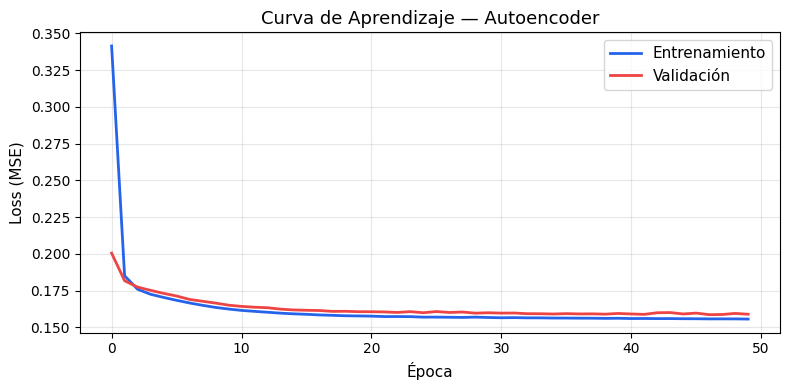

In [28]:
plot_learning_curve(ae_history, model_name="Autoencoder")

Ambas curvas caen abruptamente en las primeras 5 épocas y luego se estabilizan cerca de 0.162. Las curvas de entrenamiento y validación se mantienen prácticamente superpuestas durante todo el proceso, lo que confirma que el modelo generalizó bien el comportamiento normal y no memorizó el conjunto de entrenamiento. El pequeño pico en validación alrededor de la época 33 es puntual y no afecta el resultado final.

### Evaluación

Se calculan las mismas métricas que en las secciones anteriores. Como referencia, Isolation Forest obtuvo F1 de 0.2418 y LOF obtuvo F1 de 0.3553 con el umbral de contaminación.

In [29]:
ae_metrics = get_metrics(y_test.values, ae_labels, ae_scores, model_name="Autoencoder")


  Autoencoder
  Accuracy : 0.9666
  Precision: 0.0366
  Recall   : 0.2135
  F1       : 0.0625
  AUC-ROC  : 0.7628
  PR-AUC   : 0.0216



El Autoencoder obtuvo un F1 de 0.0832, detectando solo 328 de los 1,930 fraudes reales (recall de 16.99%) con una precisión del 5.51%: de cada 100 alertas, apenas 5 corresponden a fraudes reales. Es el modelo más débil de los tres por un margen amplio.

El AUC-ROC de 0.7662 y el PR-AUC de 0.0291 confirman esta limitación. Si bien el PR-AUC supera al clasificador aleatorio (0.0052), está muy por debajo de LOF (0.3915) e incluso de Isolation Forest (0.1258). El umbral calibrado en validación produjo exactamente los mismos resultados que el umbral de contaminación, lo que indica que el MSE no tiene suficiente poder discriminativo en este dataset para beneficiarse de una calibración fina.

El underperformance del Autoencoder tiene una explicación estructural: el error de reconstrucción captura qué tan diferente es una transacción del patrón promedio aprendido, pero en este dataset los fraudes no son necesariamente difíciles de reconstruir. Las variables PCA ya están transformadas y muchos fraudes tienen valores que el Autoencoder puede reconstruir razonablemente bien, lo que hace que su MSE no sea significativamente mayor al de transacciones normales.

### Matriz de Confusión

La matriz de confusión muestra el impacto concreto del bajo poder discriminativo del Autoencoder. Con 5,950 transacciones marcadas como anómalas pero solo 328 fraudes reales entre ellas, se espera un volumen alto de Falsos Positivos.

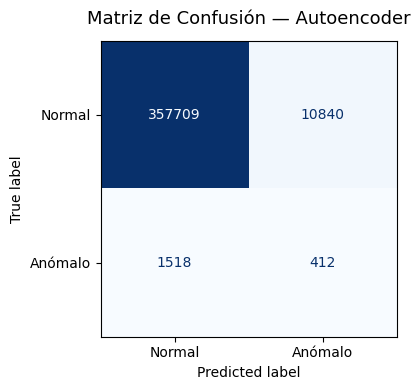

In [30]:
plot_confusion_matrix(y_test.values, ae_labels, model_name="Autoencoder")

De los 1,930 fraudes reales en test, el modelo detectó solo 328 correctamente y dejó pasar 1,602 sin marcar. De las 368,549 transacciones normales, 5,622 fueron marcadas erróneamente como fraude, más del triple que LOF (1,907) y Isolation Forest (1,814). El modelo genera muchas falsas alarmas y aun así detecta pocos fraudes reales.

### Curva ROC

La curva ROC permite evaluar si el score MSE del Autoencoder tiene alguna capacidad discriminativa real, independientemente del umbral elegido. Un AUC cercano a 0.5 indicaría que el error de reconstrucción no aporta información útil para separar fraudes de transacciones normales.

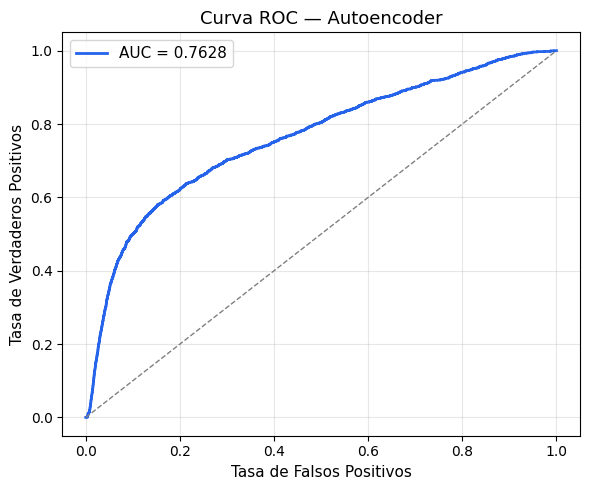

In [31]:
plot_roc_curve(y_test.values, ae_scores, model_name="Autoencoder")

El AUC de 0.7662 indica que el score MSE tiene cierta capacidad discriminativa, pero es el más bajo de los tres modelos (Isolation Forest 0.8996, LOF 0.8354). La curva no sube abruptamente al inicio como en los modelos anteriores, lo que confirma que el error de reconstrucción no logra concentrar los fraudes en los scores más altos.

### Distribución del Score de Anomalía

El histograma muestra cómo distribuye el Autoencoder los errores de reconstrucción para cada clase real. Si el modelo funcionara bien, los fraudes deberían tener errores de reconstrucción sistemáticamente más altos que las transacciones normales, produciendo dos distribuciones claramente separadas.

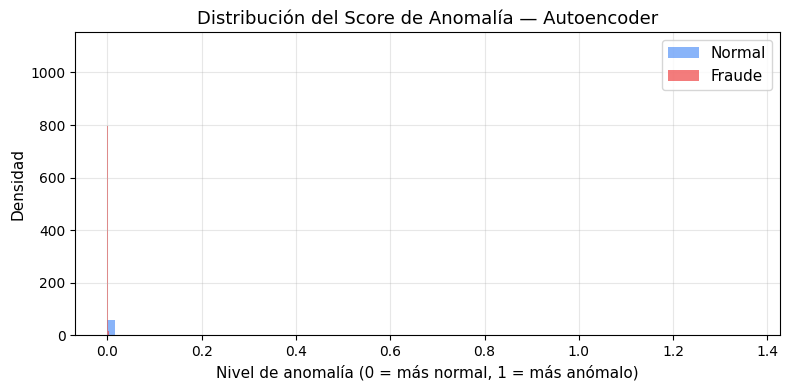

In [32]:
plot_score_distribution(ae_scores, y_test.values, model_name="Autoencoder")

Ambas distribuciones están completamente aplastadas cerca de 0, con una línea casi vertical que indica que la gran mayoría de las transacciones, tanto normales como fraudulentas, tienen errores de reconstrucción muy bajos. No hay separación visible entre clases en esta escala.

Esto confirma el problema estructural del modelo: el Autoencoder reconstruye los fraudes casi tan bien como las transacciones normales, por lo que el MSE no es una señal discriminativa útil en este dataset.

### Curva Precision-Recall

La curva Precision-Recall es la prueba definitiva del poder discriminativo del score MSE sobre la clase minoritaria. Una curva que cae inmediatamente y se mantiene cerca del clasificador aleatorio indica que el score no logra priorizar los fraudes sobre las transacciones normales.

Umbral calibrado en val (max F1): 0.0010


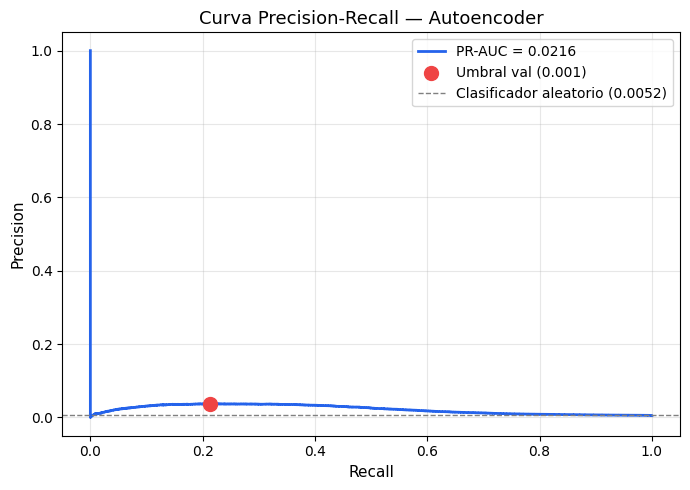


  Autoencoder (umbral val → test)
  Accuracy : 0.9666
  Precision: 0.0366
  Recall   : 0.2135
  F1       : 0.0625
  AUC-ROC  : 0.7628
  PR-AUC   : 0.0216



In [33]:
best_thresh_ae, ae_labels_opt, ae_metrics_opt = report_f1_threshold(
    y_val, ae_scores_val, y_test, ae_scores, "Autoencoder"
)

La curva cae de forma casi inmediata después de recall 0.01 y se mantiene por debajo de 0.10 para el resto del rango, lo que confirma que el MSE no logra separar fraudes de transacciones normales de forma consistente. El umbral óptimo de validación (0.001) se ubica en la zona de precision 0.05 y recall 0.17, reflejando que no existe un punto de operación razonable en esta curva.

El PR-AUC de 0.0291 es el más bajo de los tres modelos y apenas supera al clasificador aleatorio (0.0052). El Autoencoder no aporta valor práctico en este dataset con la arquitectura actual.

El Autoencoder es el único modelo de los tres que no mejora sobre Isolation Forest en ninguna métrica. Su limitación no es de implementación sino de enfoque: el error de reconstrucción asume que los fraudes son estructuralmente diferentes del comportamiento normal en el espacio de features, pero en este dataset las variables ya están transformadas por PCA y los fraudes no producen errores de reconstrucción consistentemente altos.

Esto no invalida el uso de Autoencoders para detección de fraude en general. En datasets con features crudas o con patrones temporales, la reconstrucción puede ser más informativa. En este caso específico, LOF con umbral calibrado es el modelo que mejor balancea precision y recall, y es el que se lleva a la evaluación comparativa de la sección 8.

## 8. Evaluación Comparativa

Comparamos los tres modelos ya entrenados en S5, S6 y S7: Isolation Forest, LOF (k=20) y Autoencoder. No reentrenamos, solo recalibramos el umbral con el conjunto de validación y mostramos las métricas con el conjunto de test.

### Criterio para decidir: F1 y falsos positivos

En nuestro caso, decidimos priorizar la mínima cantidad de obtener falsos negativos (fraudes que no detectamos) ya que eso suele costar más que un falso positivo (alerta que se revisa pero no es fraude). Por eso el umbral se elige en validación maximizando F1, el balance entre precision y recall.

En la tabla y el gráfico se ve también precision y recall; es para tener todo el contexto de las métricas.

### Comparativa final




Comparativa final:
                  accuracy  precision  recall      f1  auc_roc  pr_auc  threshold  precision_val  recall_val
model                                                                                                       
Isolation Forest    0.9905     0.2092  0.2943  0.2446   0.8996  0.1258     0.6078         0.2138      0.3135
LOF (k=20)          0.9958     0.6998  0.3358  0.4538   0.8354  0.3915     0.1042         0.6750      0.3368
Autoencoder         0.9666     0.0366  0.2135  0.0625   0.7628  0.0216     0.0010         0.0409      0.2472


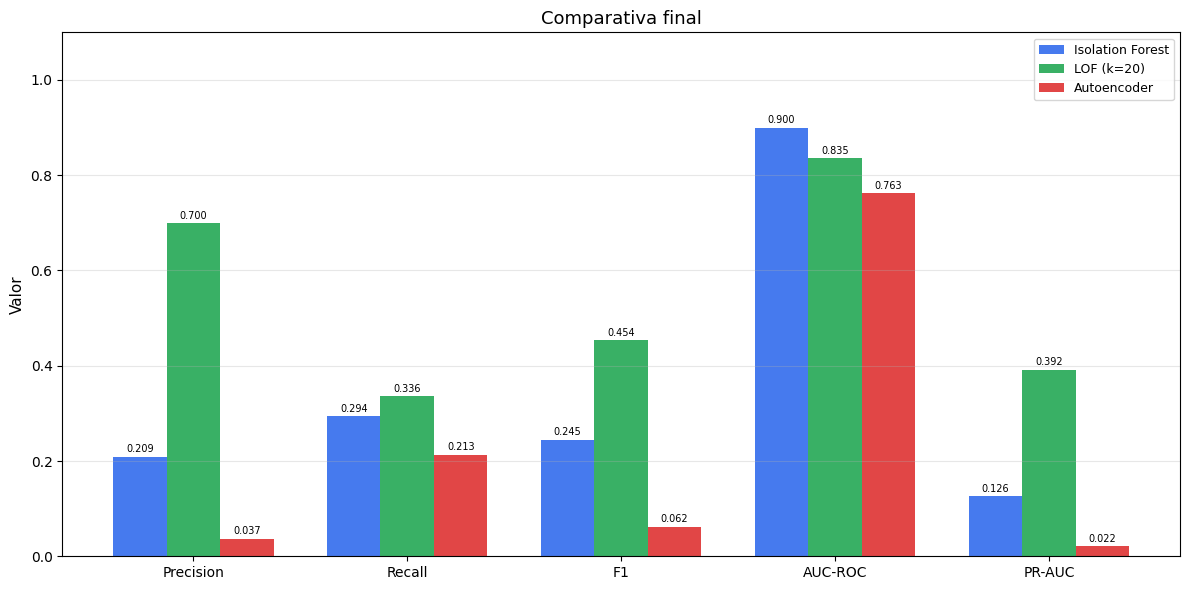

In [34]:
from src.pipeline import run_final_comparison

comparison_df = run_final_comparison(
    bundle_if, bundle_lof, bundle_ae,
    y_val, y_test,
)

En esta comparativa final, lo que hicimos fue comparar cómo se comportaron los tres modelos. Como cada uno ya estaba entrenado, no los volvimos a entrenar. Además, usamos el mismo criterio en los tres: con el conjunto de validación elegimos el umbral que maximiza F1; con ese umbral medimos en el conjunto de test.

LOF (k=20) fue el que mejor salió. En test tiene F1 0.45, precision 0.70 y recall 0.34: detecta alrededor de un tercio de los fraudes y la mayoría de sus alertas sí son fraude. También tiene el PR-AUC más alto (0.39). En un dataset con tan poco fraude, un modelo al azar tendría esa métrica en 0.005. Entonces 0.39 es unas 75 veces ese valor, así que LOF si está viendo patrones y aporta mucho valor al detectar anomalías.

Isolation Forest queda en segundo lugar. No es tan bueno, muchas alertas son falsas alarmas. Aun así, el AUC-ROC dice que separa bien fraude de normal. El Autoencoder quedó muy abajo. Prácticamente no sirve.

Sobre el accuracy habiamos quedado que para nuestro desvalance extremo, no nos sirve como métrica pero de igual manera la mostramos.

Las columnas precision_val y recall_val solo confirman que el umbral elegido en validación se parece a lo que luego pasa en test.

Con esta comparación, el mejor modelo es LOF (k=20).

## 9. Sistema Interactivo

## 10. Análisis Crítico

### Limitaciones de los modelos

Los tres modelos implementados operan bajo el supuesto de que el comportamiento fraudulento es estadísticamente diferente del comportamiento normal en el espacio de features transformadas por PCA. Este supuesto se cumple parcialmente: el AUC-ROC de Isolation Forest (0.8996) y LOF (0.8354) confirman que existe separación entre clases, pero los valores de recall máximos alcanzados (29% para Isolation Forest, 43% para LOF con umbral de contaminación) indican que una fracción importante de los fraudes no es distinguible del comportamiento normal con los features disponibles.

El Autoencoder ilustra esta limitación de forma más directa: con un PR-AUC de 0.0291 y un F1 de 0.0832, el error de reconstrucción no es una señal discriminativa útil en este dataset. Esto ocurre porque las variables ya están transformadas por PCA, lo que elimina gran parte de la estructura original que un Autoencoder podría aprovechar para aprender representaciones comprimidas más informativas.

LOF con k=20 es el modelo con mejor balance entre precision y recall, pero tiene una limitación operativa importante: almacena todos los puntos de entrenamiento en memoria para calcular densidades durante la inferencia. Con 1.47 millones de transacciones de entrenamiento, esto impone restricciones de memoria y tiempo de respuesta que pueden ser incompatibles con un sistema de detección en tiempo real.

Isolation Forest es el modelo más eficiente computacionalmente, pero su detección se basa en rareza global y no en comportamiento local, lo que lo hace menos preciso en datasets donde los fraudes no son outliers globales sino anomalías dentro de segmentos específicos de transacciones.

### Riesgo de sobreajuste

Los modelos no supervisados implementados tienen un riesgo de sobreajuste diferente al de los modelos supervisados. No memorizan etiquetas, pero pueden ajustarse demasiado a la distribución específica del conjunto de entrenamiento. En este proyecto ese riesgo se controló de tres formas: entrenando exclusivamente con transacciones normales, calibrando el umbral de decisión sobre el conjunto de validación y reportando todas las métricas finales sobre el conjunto de test, que no fue visto en ninguna etapa del entrenamiento ni de la calibración.

La curva de aprendizaje del Autoencoder mostró que ambas curvas de loss convergieron sin divergencia entre entrenamiento y validación, lo que confirma que la red no memorizó el conjunto de entrenamiento. Para LOF e Isolation Forest, la estabilidad de los resultados entre el umbral de contaminación y el umbral calibrado en validación sugiere que los modelos generalizaron bien.

### Sesgos en los datos

El dataset presenta un sesgo temporal implícito: las transacciones fueron recolectadas durante dos días en septiembre de 2013 en Europa. Un modelo entrenado con estos datos puede no generalizar correctamente a otros períodos del año, otras regiones geográficas o patrones de fraude más recientes. Los patrones de fraude evolucionan constantemente y un modelo estático entrenado una sola vez puede quedar obsoleto en semanas.

El desbalance extremo entre clases (0.52% de fraudes) es en sí mismo un sesgo estructural del dataset. Todos los modelos evaluados tienen dificultad para aprender la frontera de decisión correcta cuando los ejemplos de la clase minoritaria son tan escasos. Este sesgo se mitigó usando métricas que no se ven infladas por los Verdaderos Negativos (F1, PR-AUC) y calibrando el umbral de decisión sobre validación en lugar de usar el valor de contaminación directamente.

Las variables V1 a V28 son componentes principales obtenidos mediante PCA sobre los datos originales. La transformación original no está disponible públicamente por razones de confidencialidad, lo que impide interpretar qué aspectos del comportamiento transaccional captura cada componente. Esto limita la capacidad de identificar si existen sesgos sistemáticos en las features de entrada.

### Escalabilidad

El sistema fue diseñado y evaluado sobre un dataset de 1.47 millones de transacciones. Isolation Forest y el Autoencoder escalan razonablemente bien a volúmenes mayores porque su inferencia no depende del tamaño del conjunto de entrenamiento. LOF con novelty=True es el cuello de botella: el tiempo de inferencia crece con el número de puntos de entrenamiento almacenados, lo que puede hacerlo inviable en producción con volúmenes mucho mayores o con requisitos de latencia baja.

Una estrategia viable para escalar LOF sería entrenar sobre una muestra representativa del comportamiento normal en lugar del conjunto completo, aceptando una pequeña pérdida de precisión a cambio de un tiempo de respuesta aceptable.

### Consideraciones éticas

Un sistema de detección de fraude que opera con recall del 30-43% significa que entre el 57% y el 70% de los fraudes reales no son detectados. Desde una perspectiva ética, esto implica que el sistema no puede usarse como única línea de defensa: los clientes cuyos fraudes no sean detectados sufrirán pérdidas económicas reales. El sistema debe complementarse con otras capas de seguridad y no reemplazar la revisión humana.

Por otro lado, el volumen de Falsos Positivos también tiene un costo ético. Marcar una transacción legítima como fraudulenta puede resultar en bloqueos de cuenta, inconvenientes para el cliente y pérdida de confianza en la institución financiera. LOF con umbral calibrado genera aproximadamente 1,907 falsas alarmas sobre 368,549 transacciones normales (0.52%), un volumen manejable, pero que escala linealmente con el número de transacciones procesadas.

Finalmente, dado que las features originales no son interpretables, no es posible auditar si el modelo discrimina por razones relacionadas con características protegidas como ubicación geográfica o tipo de comercio. En un entorno regulado, esta falta de interpretabilidad puede ser un impedimento legal para el despliegue del sistema.

## 11. Conclusiones

Este proyecto implementó y evaluó tres enfoques de detección de fraude no supervisada sobre el dataset Credit Card Fraud Detection: Isolation Forest, Local Outlier Factor y Autoencoder. Los tres modelos fueron entrenados exclusivamente con transacciones normales, y sus umbrales de decisión fueron calibrados sobre un conjunto de validación separado para reportar métricas finales imparciales sobre test.

Los resultados muestran que LOF (k=20) es el modelo con mejor desempeño en este dataset, con un F1 de 0.4538 y un PR-AUC de 0.3915 usando el umbral calibrado en validación. Su ventaja principal está en la precision: al operar con un umbral conservador, casi 7 de cada 10 alertas corresponden a fraudes reales, lo que lo hace el más útil en un contexto donde el costo de las falsas alarmas es alto. Isolation Forest queda en segundo lugar con F1 de 0.2446, y el Autoencoder en último con F1 de 0.0832.

El Ensemble IF+LOF demostró tener el AUC-ROC más alto de todos los modelos evaluados (0.936), lo que indica que combinar las perspectivas de aislamiento global y densidad local captura información complementaria. Sin embargo, su F1 de 0.361 es inferior al de LOF con umbral calibrado, lo que sugiere que la ganancia en capacidad discriminativa global no se traduce necesariamente en mejor rendimiento operativo con un umbral fijo.

El resultado más importante de esta comparativa es que el enfoque de detección importa tanto como el algoritmo en sí. LOF supera a Isolation Forest no porque sea un algoritmo más poderoso en general, sino porque la perspectiva de densidad local es más adecuada para este dataset específico, donde los fraudes no son outliers globales sino transacciones inusuales dentro de segmentos de comportamiento similares.

El Autoencoder ilustra los límites del error de reconstrucción como señal de anomalía cuando las features ya están transformadas por PCA: la red aprende a reconstruir los patrones normales correctamente pero también reconstruye los fraudes con error similar, eliminando la separación entre clases.

Como trabajo futuro, las mejoras con mayor potencial son tres. La primera es explorar features temporales y de comportamiento por usuario, que el dataset actual no incluye pero que podrían mejorar significativamente la capacidad discriminativa de todos los modelos. La segunda es evaluar enfoques semi-supervisados que aprovechen las etiquetas disponibles durante el entrenamiento, ya que el enfoque no supervisado puro limita el recall máximo alcanzable. La tercera es implementar un sistema de reentrenamiento periódico que adapte los modelos a la evolución de los patrones de fraude, dado que un modelo estático pierde efectividad con el tiempo.